In [1]:
%%time
%pip install pandas scikit-learn matplotlib
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 75.6 MB/s eta 0:00:00
  Attempting uninstall: torch
    Found existing installation: torch 2.9.0+cpu
    Uninstalling torch-2.9.0+cpu:
      Successfully uninstalled torch-2.9.0+cpu
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.24.0+cpu
    Uninstalling torchvision-0.24.0+cpu:
      Successfully uninstalled torchvision-0.24.0+cpu
  Attempting uninstall: torchaudio
    Found existing installation: torchaudio 2.9.0+cpu
    Uninstalling torchaudio-2.9.0+cpu:
      Successfully uninstalled torchaudio-2.9.0+cpu
CPU times: user 2.97 s, sys: 428 ms, total: 3.39 s
Wall time: 51.1 s


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


In [3]:
#step1

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/rk7VDaPjMp1h5VXS-cUyMg/league-of-legends-data-large.csv"
data = pd.read_csv(url)

data.head()


,win,kills,deaths,assists,gold_earned,cs,wards_placed,wards_killed,damage_dealt
0,0,16,6,19,17088,231,11,7,15367
1,1,8,8,5,14865,259,10,2,38332
2,0,0,17,11,15919,169,14,5,24642
3,0,19,11,1,11534,264,14,3,15789
4,0,12,7,6,18926,124,15,7,40268


In [4]:
X = data.drop('win', axis=1)
y = data['win']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [7]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


In [8]:
#ex2
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))


In [9]:
input_dim = X_train.shape[1]

model = LogisticRegressionModel(input_dim)
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)


In [10]:
#ex3
epochs = 1000

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [100/1000], Loss: 0.7307
Epoch [200/1000], Loss: 0.7131
Epoch [300/1000], Loss: 0.7021
Epoch [400/1000], Loss: 0.6955
Epoch [500/1000], Loss: 0.6914
Epoch [600/1000], Loss: 0.6890
Epoch [700/1000], Loss: 0.6875
Epoch [800/1000], Loss: 0.6866
Epoch [900/1000], Loss: 0.6861
Epoch [1000/1000], Loss: 0.6858


In [11]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train)
    test_preds = model(X_test)

train_preds = (train_preds >= 0.5).float()
test_preds = (test_preds >= 0.5).float()

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Training Accuracy: 0.54875
Test Accuracy: 0.495


In [12]:
#ex4
model_l2 = LogisticRegressionModel(input_dim)
criterion = nn.BCELoss()
optimizer_l2 = optim.SGD(model_l2.parameters(), lr=0.01, weight_decay=0.01)


In [13]:
for epoch in range(epochs):
    optimizer_l2.zero_grad()
    outputs = model_l2(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer_l2.step()


In [14]:
model_l2.eval()
with torch.no_grad():
    preds = model_l2(X_test)

preds = (preds >= 0.5).float()
print("Test Accuracy with L2:", accuracy_score(y_test, preds))


Test Accuracy with L2: 0.52


In [15]:
#ex5
cm = confusion_matrix(y_test, preds)
print(cm)


[[41 54]
 [42 63]]


In [16]:
print(classification_report(y_test, preds))


              precision    recall  f1-score   support

         0.0       0.49      0.43      0.46        95
         1.0       0.54      0.60      0.57       105

    accuracy                           0.52       200
   macro avg       0.52      0.52      0.51       200
weighted avg       0.52      0.52      0.52       200



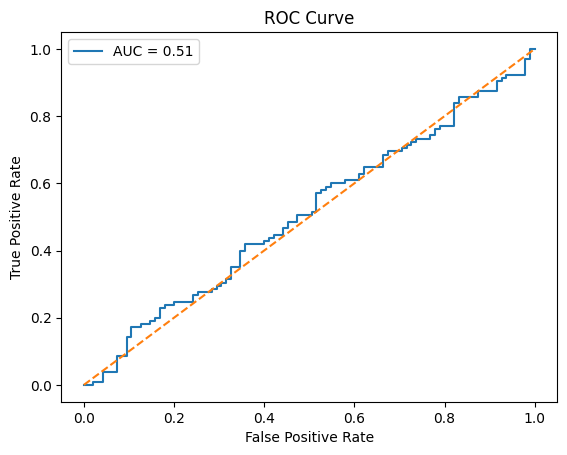

In [17]:
with torch.no_grad():
    probs = model_l2(X_test).numpy()

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [18]:
#ex6
torch.save(model_l2.state_dict(), "lol_logistic_model.pth")


In [19]:
loaded_model = LogisticRegressionModel(input_dim)
loaded_model.load_state_dict(torch.load("lol_logistic_model.pth"))
loaded_model.eval()


LogisticRegressionModel(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)

In [20]:
with torch.no_grad():
    preds = loaded_model(X_test)
preds = (preds >= 0.5).float()

print("Loaded Model Accuracy:", accuracy_score(y_test, preds))


Loaded Model Accuracy: 0.52


In [21]:
#ex7
learning_rates = [0.01, 0.05, 0.1]

for lr in learning_rates:
    model_temp = LogisticRegressionModel(input_dim)
    optimizer = optim.SGD(model_temp.parameters(), lr=lr)

    for _ in range(100):
        optimizer.zero_grad()
        loss = criterion(model_temp(X_train), y_train)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        preds = (model_temp(X_test) >= 0.5).float()
        acc = accuracy_score(y_test, preds)

    print(f"LR={lr} → Test Accuracy={acc}")


LR=0.01 → Test Accuracy=0.53
LR=0.05 → Test Accuracy=0.53
LR=0.1 → Test Accuracy=0.5


In [22]:
#ex8
weights = model_l2.linear.weight.data.numpy().flatten()
features = data.drop('win', axis=1).columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': weights
})

importance_df['AbsImportance'] = importance_df['Importance'].abs()
importance_df = importance_df.sort_values(by='AbsImportance', ascending=False)


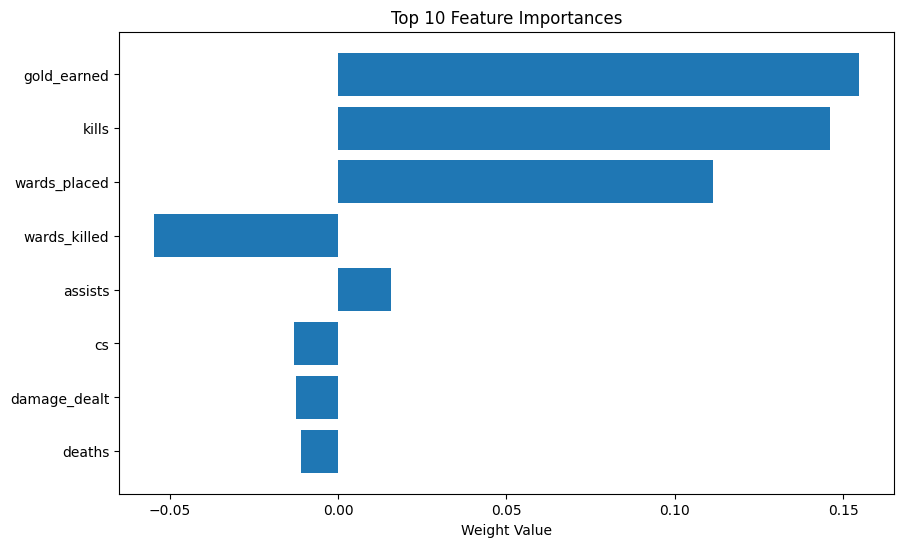

In [23]:
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.xlabel("Weight Value")
plt.show()
